In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [6]:

df = pd.read_csv("/kaggle/input/datasets/dhrubangtalukdar/startup-funding-and-outcome-dataset/startup_success_dataset.csv")

## *4- Final Model Evaluation*

              precision    recall  f1-score   support

 Acquisition       0.69      0.68      0.68      8467
     Failure       0.78      0.78      0.78     11122
         IPO       0.41      0.50      0.45       411

    accuracy                           0.73     20000
   macro avg       0.63      0.65      0.64     20000
weighted avg       0.73      0.73      0.73     20000



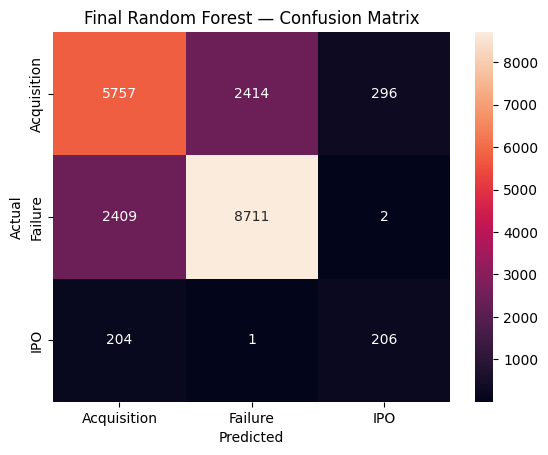

In [36]:
# Our selected model is: Tuned Random Forest, default 0.50 threshold
y_pred_final = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_final))

cm_final = confusion_matrix(y_test, y_pred_final)

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    xticklabels=best_rf.classes_,
    yticklabels=best_rf.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Random Forest — Confusion Matrix")
plt.show()

In [37]:
# model comparison 

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_final)
    ],
    "Macro F1": [
        f1_score(y_test, y_pred_lr, average="macro"),
        f1_score(y_test, y_pred_rf, average="macro"),
        f1_score(y_test, y_pred_final, average="macro")
    ],
    "IPO F1": [
        f1_score(y_test, y_pred_lr, labels=["IPO"], average="macro"),
        f1_score(y_test, y_pred_rf, labels=["IPO"], average="macro"),
        f1_score(y_test, y_pred_final, labels=["IPO"], average="macro")
    ]
})

comparison.round(3)

,Model,Accuracy,Macro F1,IPO F1
0,Logistic Regression,0.686,0.564,0.302
1,Random Forest,0.736,0.542,0.157
2,Tuned Random Forest,0.734,0.639,0.450


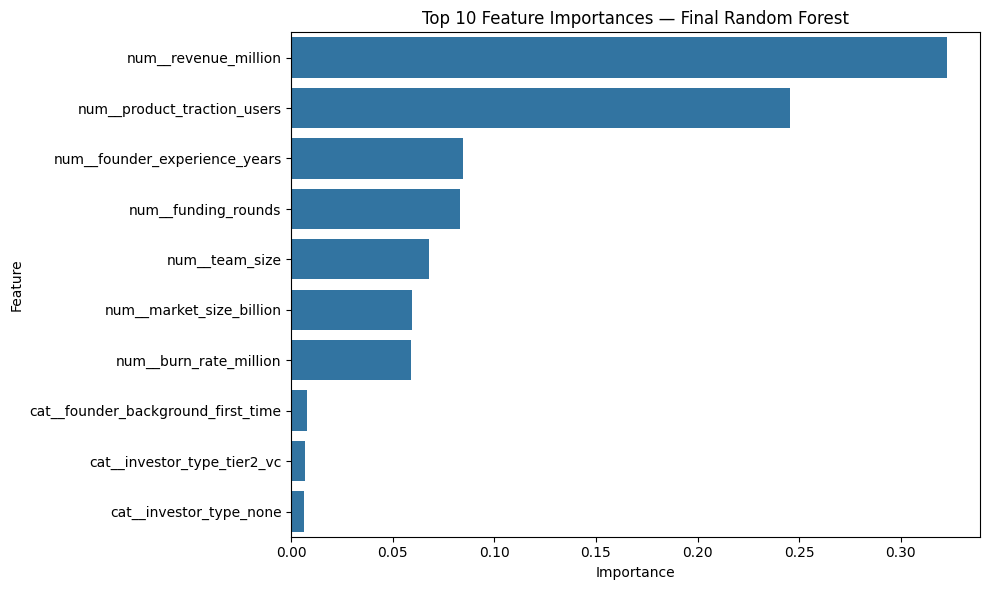

In [38]:
# Feature Importance

feature_names = best_rf.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = best_rf.named_steps[
    "classifier"
].feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="importance",
    y="feature"
)

plt.title("Top 10 Feature Importances — Final Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## *3- Data Preparation for ML.*

In [7]:
# separate features and verify separation

X = df.drop("outcome", axis=1)
y = df["outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print(X.columns.tolist())

print(y.value_counts())

X shape: (100000, 10)
y shape: (100000,)
['funding_rounds', 'founder_experience_years', 'team_size', 'market_size_billion', 'product_traction_users', 'burn_rate_million', 'revenue_million', 'investor_type', 'sector', 'founder_background']
outcome
Failure        55610
Acquisition    42335
IPO             2055
Name: count, dtype: int64


In [8]:
# splitting 

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y #It keeps approximately the same outcome distribution in both datasets.
)

#verify split 

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# check training and test distribution 
y_train.value_counts(normalize=True) * 100
y_test.value_counts(normalize=True) * 100

X_train: (80000, 10)
X_test: (20000, 10)
y_train: (80000,)
y_test: (20000,)


outcome
Failure        55.610
Acquisition    42.335
IPO             2.055
Name: proportion, dtype: float64

In [9]:
# check if any data leakage from split 
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Total:", len(X_train) + len(X_test))

Training rows: 80000
Testing rows: 20000
Total: 100000


In [10]:
#identify feature type

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['funding_rounds', 'founder_experience_years', 'team_size', 'market_size_billion', 'product_traction_users', 'burn_rate_million', 'revenue_million']

Categorical features:
['investor_type', 'sector', 'founder_background']


In [11]:
# Preprocessing

numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Fit only on training data
preprocessor.fit(X_train)

# Transform training/test data
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Check shapes
print("Original training shape:", X_train.shape)
print("Original test shape:", X_test.shape)
print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

# Get names of transformed features
feature_names = preprocessor.get_feature_names_out()

print("\nNumber of processed features:", len(feature_names))
print("\nFirst 15 processed feature names:")
print(feature_names[:15])

# Show a few processed rows
print("\nFirst 5 rows of processed training data:")
print(X_train_processed[:5].toarray() if hasattr(X_train_processed, "toarray") else X_train_processed[:5])

Original training shape: (80000, 10)
Original test shape: (20000, 10)
Processed training shape: (80000, 22)
Processed test shape: (20000, 22)

Number of processed features: 22

First 15 processed feature names:
['num__funding_rounds' 'num__founder_experience_years' 'num__team_size'
 'num__market_size_billion' 'num__product_traction_users'
 'num__burn_rate_million' 'num__revenue_million'
 'cat__investor_type_angel' 'cat__investor_type_none'
 'cat__investor_type_tier1_vc' 'cat__investor_type_tier2_vc'
 'cat__sector_AI' 'cat__sector_Climate' 'cat__sector_Crypto'
 'cat__sector_Ecommerce']

First 5 rows of processed training data:
[[ 0.70269633  0.82974483 -1.23712525 -0.61869743 -1.06993159 -0.62308607
  -0.70742046  0.          1.          0.          0.          1.
   0.          0.          0.          0.          0.          0.
   0.          0.          1.          0.        ]
 [-0.71039769  0.96833562  1.40587564  1.22248374 -1.21829128  3.81761133
  -0.69585358  1.          0.      

In [12]:
# combines preprocessing + model so preprocessing is handled correctly as part of training.

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])
#train
logistic_model.fit(X_train, y_train)
#test
y_pred_lr = logistic_model.predict(X_test)
#Check prediction distribution
print(pd.Series(y_pred_lr).value_counts())
print()
print(pd.Series(y_pred_lr).value_counts(normalize=True) * 100)

Failure        10816
Acquisition     7343
IPO             1841
Name: count, dtype: int64

Failure        54.080
Acquisition    36.715
IPO             9.205
Name: proportion, dtype: float64


In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(cm_lr)


Accuracy: 0.68575
              precision    recall  f1-score   support

 Acquisition       0.65      0.57      0.61      8467
     Failure       0.79      0.77      0.78     11122
         IPO       0.18      0.83      0.30       411

    accuracy                           0.69     20000
   macro avg       0.54      0.72      0.56     20000
weighted avg       0.72      0.69      0.70     20000

[[4798 2238 1431]
 [2475 8577   70]
 [  70    1  340]]


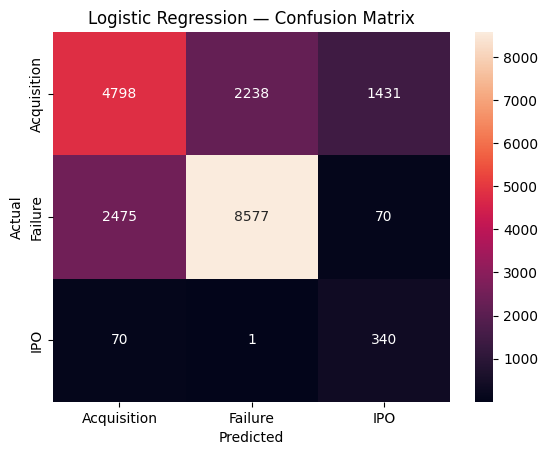

In [14]:
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=logistic_model.classes_,
    yticklabels=logistic_model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

In [15]:
lr_results = {
    "model": "Logistic Regression",
    "accuracy": accuracy_score(y_test, y_pred_lr),
    "macro_f1": f1_score(y_test, y_pred_lr, average="macro"),
    "ipo_precision": precision_score(y_test, y_pred_lr, labels=["IPO"], average="macro"),
    "ipo_recall": recall_score(y_test, y_pred_lr, labels=["IPO"], average="macro"),
    "ipo_f1": f1_score(y_test, y_pred_lr, labels=["IPO"], average="macro")
}

print(lr_results)

{'model': 'Logistic Regression', 'accuracy': 0.68575, 'macro_f1': 0.5636141122493334, 'ipo_precision': 0.18468223791417707, 'ipo_recall': 0.8272506082725061, 'ipo_f1': 0.3019538188277087}


In [16]:
# Random forest 

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [17]:
print(pd.Series(y_pred_rf).value_counts())
print()
print(pd.Series(y_pred_rf).value_counts(normalize=True) * 100)

Failure        11982
Acquisition     7970
IPO               48
Name: count, dtype: int64

Failure        59.91
Acquisition    39.85
IPO             0.24
Name: proportion, dtype: float64


In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7364
              precision    recall  f1-score   support

 Acquisition       0.70      0.66      0.68      8467
     Failure       0.76      0.82      0.79     11122
         IPO       0.75      0.09      0.16       411

    accuracy                           0.74     20000
   macro avg       0.74      0.52      0.54     20000
weighted avg       0.73      0.74      0.73     20000



In [20]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[5583 2872   12]
 [2013 9109    0]
 [ 374    1   36]]


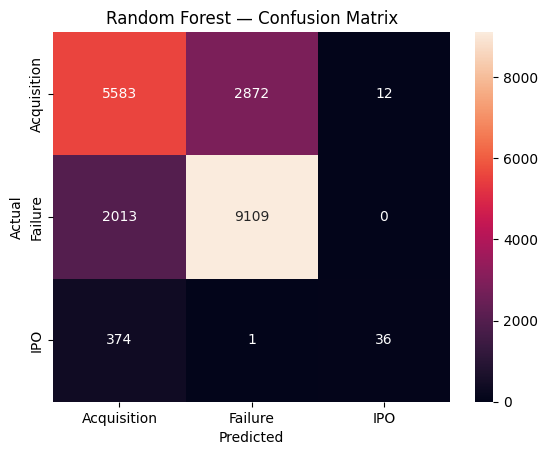

In [21]:
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=rf_model.classes_,
    yticklabels=rf_model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest — Confusion Matrix")
plt.show()

**Probability analysis**

In [23]:
# Probability analysis

y_proba_rf = rf_model.predict_proba(X_test)

print("Probability shape:", y_proba_rf.shape)
print("Classes:", rf_model.classes_)

Probability shape: (20000, 3)
Classes: ['Acquisition' 'Failure' 'IPO']


In [24]:
ipo_index = list(rf_model.classes_).index("IPO")

ipo_probabilities = y_proba_rf[:, ipo_index]

print("Average IPO probability:", ipo_probabilities.mean())
print("Maximum IPO probability:", ipo_probabilities.max())

Average IPO probability: 0.019502500000000002
Maximum IPO probability: 0.745


In [25]:
actual_ipo_probs = ipo_probabilities[y_test == "IPO"]

print("Actual IPO cases:", len(actual_ipo_probs))
print("Average IPO probability:", actual_ipo_probs.mean())
print("Maximum IPO probability:", actual_ipo_probs.max())

Actual IPO cases: 411
Average IPO probability: 0.2305961070559611
Maximum IPO probability: 0.745


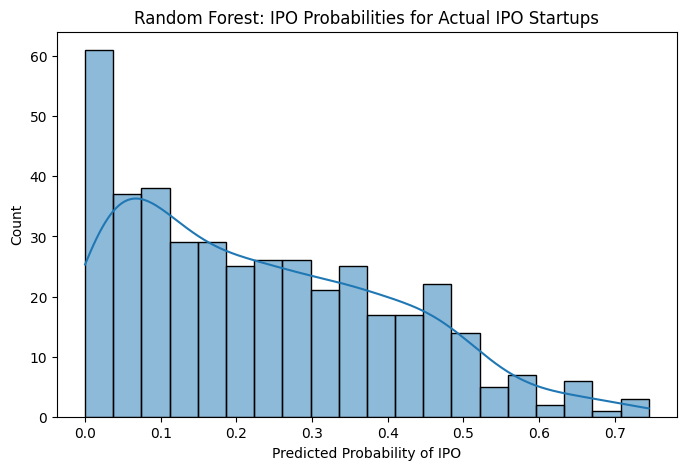

In [26]:
plt.figure(figsize=(8, 5))

sns.histplot(
    actual_ipo_probs,
    bins=20,
    kde=True
)

plt.title("Random Forest: IPO Probabilities for Actual IPO Startups")
plt.xlabel("Predicted Probability of IPO")
plt.ylabel("Count")

plt.show()

**threshold values testing**

In [27]:
# threshold values testing 


thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = np.where(
        ipo_probabilities >= threshold,
        "IPO",
        y_pred_rf
    )

    threshold_results.append({
        "threshold": threshold,
        "ipo_precision": precision_score(
            y_test, y_pred_threshold,
            labels=["IPO"], average="macro"
        ),
        "ipo_recall": recall_score(
            y_test, y_pred_threshold,
            labels=["IPO"], average="macro"
        ),
        "ipo_f1": f1_score(
            y_test, y_pred_threshold,
            labels=["IPO"], average="macro"
        ),
        "macro_f1": f1_score(
            y_test, y_pred_threshold,
            average="macro"
        ),
        "accuracy": accuracy_score(
            y_test, y_pred_threshold
        )
    })
threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(3)

,threshold,ipo_precision,ipo_recall,ipo_f1,macro_f1,accuracy
0,0.10,0.262,0.703,0.382,0.598,0.710
1,0.15,0.337,0.599,0.432,0.623,0.724
2,0.20,0.402,0.506,0.448,0.633,0.730
3,0.25,0.464,0.421,0.441,0.633,0.734
4,0.30,0.530,0.341,0.415,0.626,0.736
5,0.40,0.672,0.200,0.308,0.592,0.737
6,0.50,0.750,0.088,0.157,0.542,0.736


**Class-weight experiment**

In [35]:
#Class-weight experiment

class_weights = [
    {"Failure": 1, "Acquisition": 1, "IPO": 2},
    {"Failure": 1, "Acquisition": 1, "IPO": 3},
    {"Failure": 1, "Acquisition": 1, "IPO": 5}
]

weighted_results = []

for weights in class_weights:

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            class_weight=weights,
            random_state=42,
            n_jobs=-1
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    weighted_results.append({
        "weights": weights,
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
        "ipo_precision": precision_score(
            y_test, y_pred,
            labels=["IPO"],
            average="macro"
        ),
        "ipo_recall": recall_score(
            y_test, y_pred,
            labels=["IPO"],
            average="macro"
        ),
        "ipo_f1": f1_score(
            y_test, y_pred,
            labels=["IPO"],
            average="macro"
        )
    })

weighted_results_df = pd.DataFrame(weighted_results)

weighted_results_df.round(3)

,weights,accuracy,macro_f1,ipo_precision,ipo_recall,ipo_f1
0,"{'Failure': 1, 'Acquisition': 1, 'IPO': 2}",0.739,0.574,0.721,0.151,0.249
1,"{'Failure': 1, 'Acquisition': 1, 'IPO': 3}",0.736,0.567,0.734,0.141,0.237
2,"{'Failure': 1, 'Acquisition': 1, 'IPO': 5}",0.735,0.564,0.743,0.134,0.227


**RF tuning**

In [33]:
# RF tuning ============================================================
# Step 1 — Define a small search space
# We tune only the parameters that matter most for tree
# complexity and generalization (not everything, to keep
# the search space manageable).
# ============================================================
rf_params = {
    "max_depth": [10, 20, None],       # controls how complex each tree can become
    "min_samples_leaf": [1, 5, 10],    # prevents overly specific rules
    "max_features": ["sqrt", "log2"]   # controls how many features each split considers
}

# ============================================================
# Step 2 — Use RandomizedSearchCV instead of manually training
# every combination
# ============================================================
from sklearn.model_selection import RandomizedSearchCV

# ------------------------------------------------------------
# Create the base pipeline
# ------------------------------------------------------------
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# ============================================================
# Step 3 — Create the randomized search
#
# Why scoring="f1_macro"?
# Our classes are highly imbalanced, so optimizing accuracy
# could encourage the model to focus on Failure and Acquisition.
# Macro F1 gives each class equal importance, including IPO —
# more aligned with our project goal.
# ============================================================
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions={
        f"classifier__{key}": value
        for key, value in rf_params.items()
    },
    n_iter=10,
    scoring="f1_macro",
    cv=3,
    random_state=42,
    n_jobs=-1
)

# ============================================================
# Step 4 — Train the search
# This may take some time since we're training multiple Random
# Forest configurations using 3-fold cross-validation.
# ============================================================
random_search.fit(X_train, y_train)

# ============================================================
# Step 5 — See the best parameters and best CV score
# ============================================================
print("Best parameters:")
print(random_search.best_params_)

print("Best CV Macro F1:", random_search.best_score_)

# ============================================================
# Step 6 — Evaluate on the untouched test set
# (The test set has not been used during tuning.)
# ============================================================
best_rf = random_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_tuned))

print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Macro F1:", f1_score(y_test, y_pred_tuned, average="macro"))

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters:
{'classifier__min_samples_leaf': 5, 'classifier__max_features': 'sqrt', 'classifier__max_depth': None}
Best CV Macro F1: 0.6320221396643816
              precision    recall  f1-score   support

 Acquisition       0.69      0.68      0.68      8467
     Failure       0.78      0.78      0.78     11122
         IPO       0.41      0.50      0.45       411

    accuracy                           0.73     20000
   macro avg       0.63      0.65      0.64     20000
weighted avg       0.73      0.73      0.73     20000

Accuracy: 0.7337
Macro F1: 0.6390686305685208


**repeat the probability-threshold experiment on the tuned Random Forest.**

In [34]:
#repeat the probability-threshold experiment on the tuned Random Forest.
y_proba_tuned = best_rf.predict_proba(X_test)

ipo_index = list(best_rf.classes_).index("IPO")

ipo_probabilities_tuned = y_proba_tuned[:, ipo_index]

print("Probability shape:", y_proba_tuned.shape)
print("Average IPO probability:", ipo_probabilities_tuned.mean())
print("Maximum IPO probability:", ipo_probabilities_tuned.max())

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

threshold_results_tuned = []

for threshold in thresholds:

    y_pred_threshold = np.where(
        ipo_probabilities_tuned >= threshold,
        "IPO",
        y_pred_tuned
    )

    threshold_results_tuned.append({
        "threshold": threshold,
        "ipo_precision": precision_score(
            y_test,
            y_pred_threshold,
            labels=["IPO"],
            average="macro"
        ),
        "ipo_recall": recall_score(
            y_test,
            y_pred_threshold,
            labels=["IPO"],
            average="macro"
        ),
        "ipo_f1": f1_score(
            y_test,
            y_pred_threshold,
            labels=["IPO"],
            average="macro"
        ),
        "macro_f1": f1_score(
            y_test,
            y_pred_threshold,
            average="macro"
        ),
        "accuracy": accuracy_score(
            y_test,
            y_pred_threshold
        )
    })

threshold_df_tuned = pd.DataFrame(threshold_results_tuned)

threshold_df_tuned.round(3)

Probability shape: (20000, 3)
Average IPO probability: 0.052704684815809685
Maximum IPO probability: 0.9500351460530616


,threshold,ipo_precision,ipo_recall,ipo_f1,macro_f1,accuracy
0,0.10,0.136,0.876,0.236,0.519,0.652
1,0.15,0.175,0.839,0.290,0.554,0.679
2,0.20,0.211,0.786,0.333,0.579,0.697
3,0.25,0.253,0.742,0.377,0.601,0.710
4,0.30,0.290,0.696,0.409,0.616,0.718
5,0.40,0.347,0.574,0.432,0.630,0.728
6,0.50,0.409,0.501,0.450,0.639,0.734


## *2- EDA*

<Axes: xlabel='outcome'>

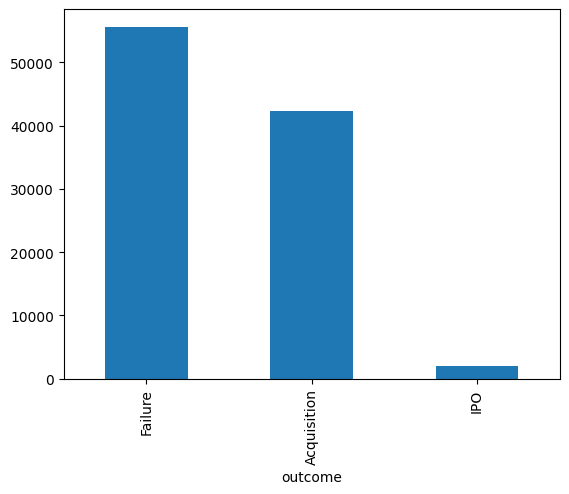

In [4]:
#1- Is the target balanced?
df["outcome"].value_counts().plot(kind="bar")

In [5]:
df["outcome"].value_counts(normalize=True) * 100

outcome
Failure        55.610
Acquisition    42.335
IPO             2.055
Name: proportion, dtype: float64

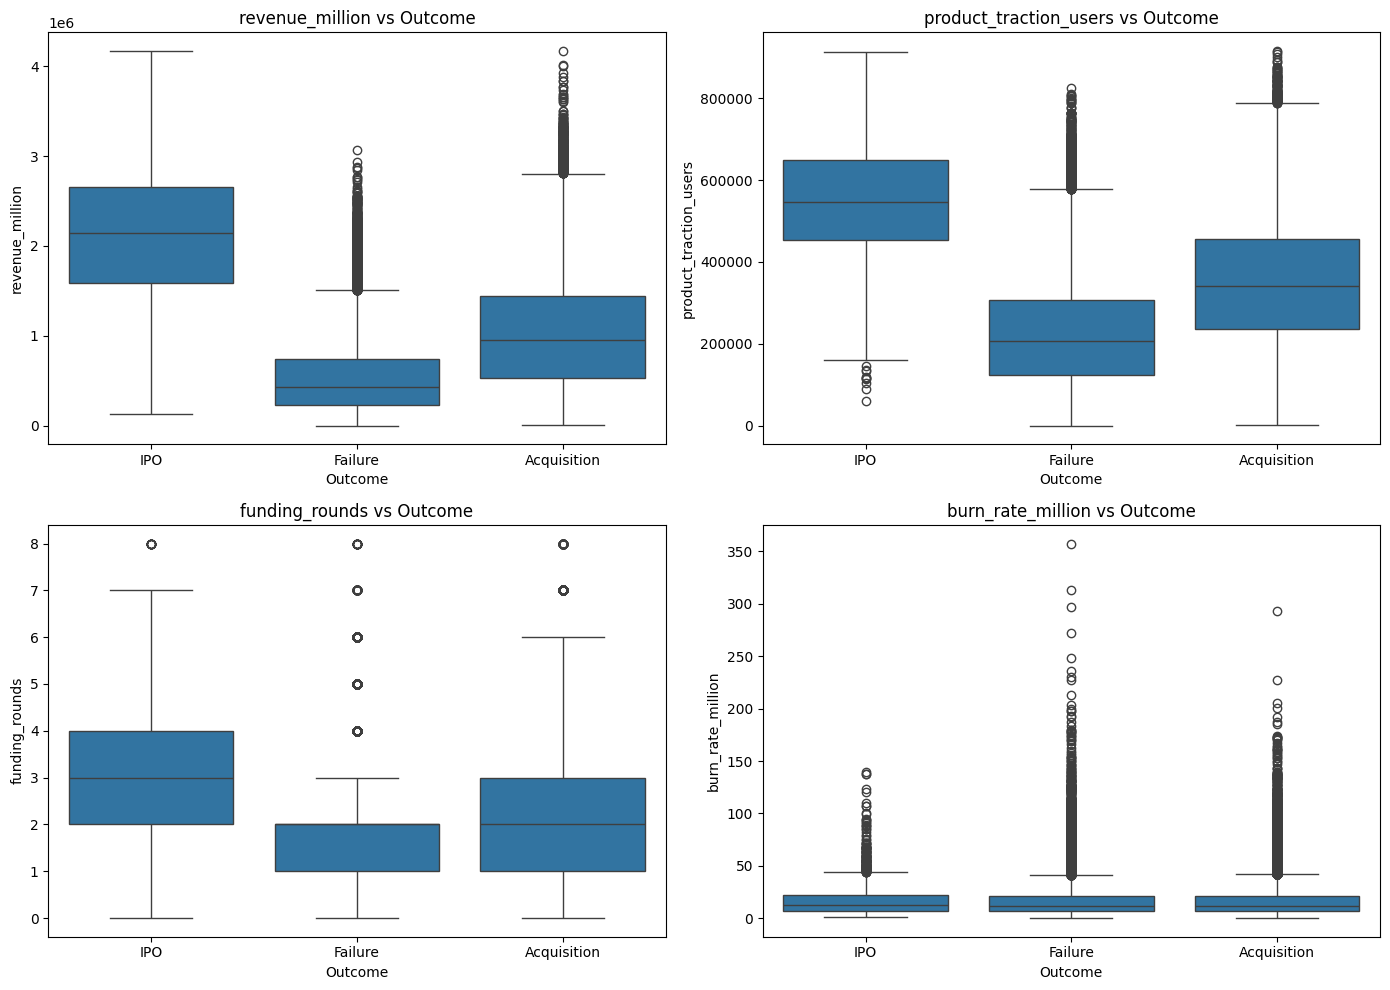

In [21]:
# 2- Which numerical features differ by outcome?

import matplotlib.pyplot as plt
import seaborn as sns

features = [
    "revenue_million",
    "product_traction_users",
    "funding_rounds",
    "burn_rate_million"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.flat, features):
    sns.boxplot(
        data=df,
        x="outcome",
        y=feature,
        ax=ax
    )
    ax.set_title(f"{feature} vs Outcome")
    ax.set_xlabel("Outcome")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()


* Line in the middle of the box (~3): the median — half of IPO companies had 3 or fewer funding rounds, half had more
* Box itself (from 2 to 4): the IQR (interquartile range) — the middle 50% of IPO companies fall between 2 and 4 funding rounds.
* This is where "most" companies sit.Whiskers (lines sticking out, 0 to 7): the typical full range of the data, excluding extreme outliers
* Circles above the whisker (the "8" dot): outliers — a company that got 8 funding rounds, unusually high compared to the rest of the IPO group


In [23]:
features = [
    "revenue_million",
    "product_traction_users",
    "funding_rounds",
    "burn_rate_million"
]

df.groupby("outcome")[features].agg(["mean", "median", "min", "max"]).T

outcome                         Acquisition       Failure           IPO
revenue_million        mean    1.041604e+06  5.363789e+05  2.120475e+06
                       median  9.491657e+05  4.341426e+05  2.144511e+06
                       min     2.971611e+03  1.344810e+03  1.277344e+05
                       max     4.168443e+06  3.062887e+06  4.163782e+06
product_traction_users mean    3.508720e+05  2.259055e+05  5.476956e+05
                       median  3.424040e+05  2.059085e+05  5.477520e+05
                       min     2.163000e+03  6.680000e+02  6.153600e+04
                       max     9.152030e+05  8.243940e+05  9.126070e+05
funding_rounds         mean    2.346593e+00  1.703363e+00  2.999027e+00
                       median  2.000000e+00  2.000000e+00  3.000000e+00
                       min     0.000000e+00  0.000000e+00  0.000000e+00
                       max     8.000000e+00  8.000000e+00  8.000000e+00
burn_rate_million      mean    1.683388e+01  1.671574e+01  1.722460e+01
                       median  1.214947e+01  1.217541e+01  1.247564e+01
                       min     3.669232e-01  2.797632e-01  9.482695e-01
                       max     2.927617e+02  3.574915e+02  1.398208e+02


INVESTOR_TYPE
outcome        Acquisition  Failure  IPO
investor_type                           
angel                 41.9     55.9  2.2
none                  42.7     55.2  2.1
tier1_vc              42.4     55.7  1.9
tier2_vc              42.3     55.7  2.0


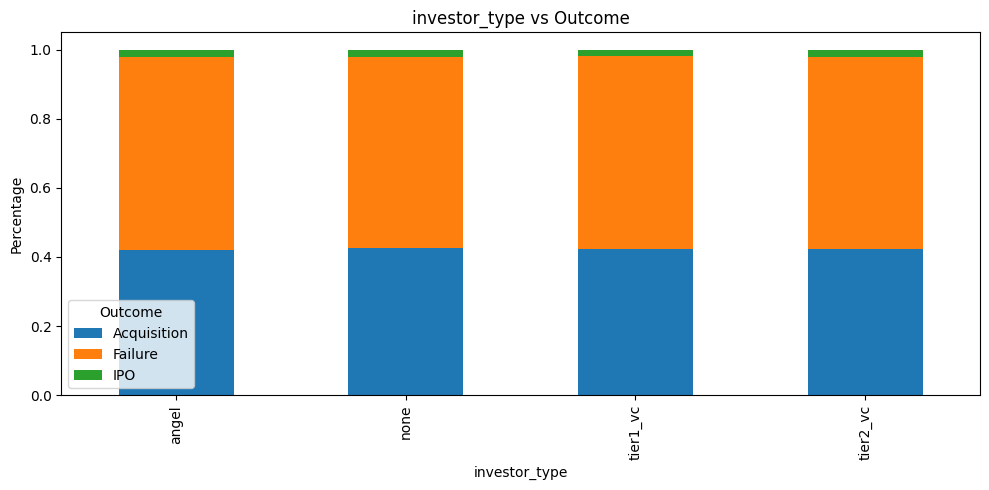


SECTOR
outcome    Acquisition  Failure  IPO
sector                              
AI                42.3     55.9  1.8
Climate           42.3     55.5  2.2
Crypto            42.8     55.1  2.1
Ecommerce         42.4     55.6  2.0
Fintech           41.6     56.3  2.1
Health            42.7     55.2  2.1
SaaS              42.2     55.7  2.0


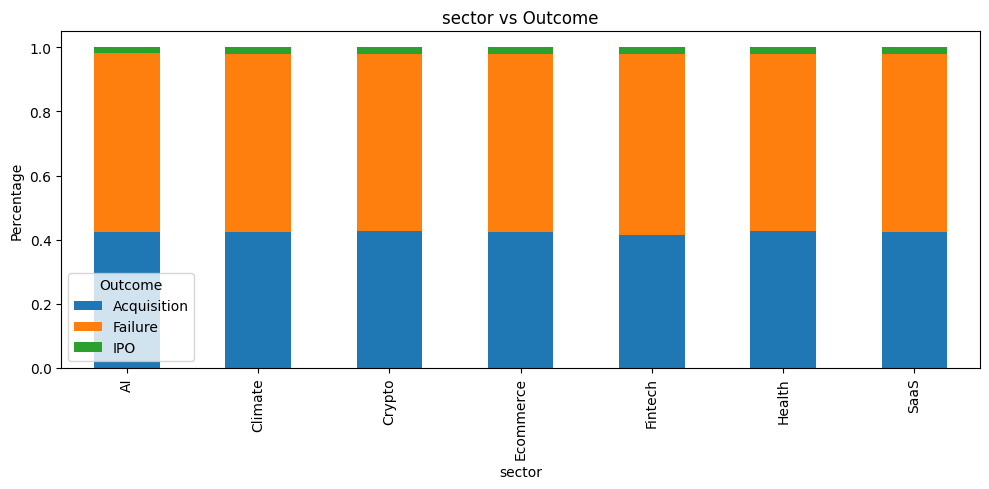


FOUNDER_BACKGROUND
outcome             Acquisition  Failure  IPO
founder_background                           
academic                   41.7     56.2  2.1
ex_bigtech                 42.2     55.8  2.1
first_time                 42.6     55.4  2.0
serial_founder             42.8     55.2  2.0


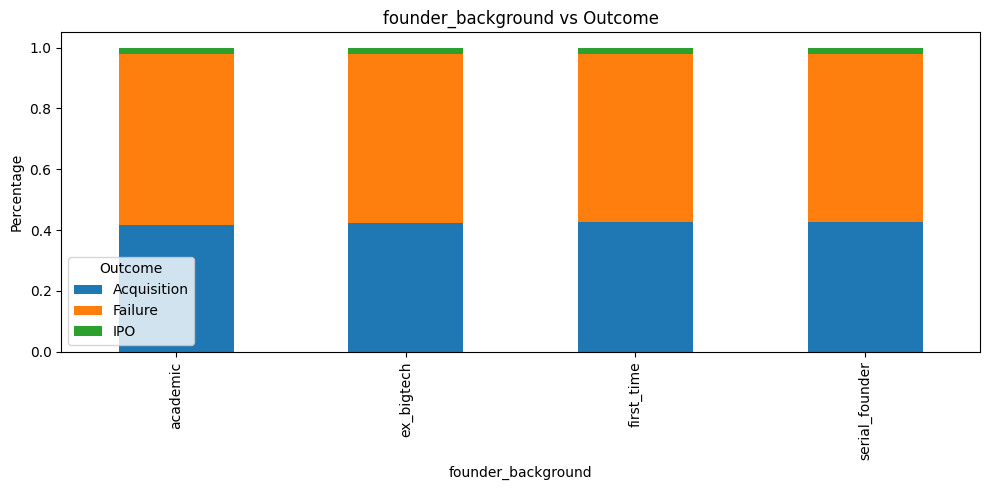

In [4]:
# 3-Does startup outcome vary depending on investor type, sector, or founder background?
#Categorical Features vs Outcome
import matplotlib.pyplot as plt
categorical_features = [
    "investor_type",
    "sector",
    "founder_background"
]
for feature in categorical_features:
    print(f"\n{'='*50}")
    print(feature.upper())
    print(
        pd.crosstab(
            df[feature],
            df["outcome"],
            normalize="index"
        ).round(3) * 100
    )

    pd.crosstab(
        df[feature],
        df["outcome"],
        normalize="index"
    ).plot(
        kind="bar",
        stacked=True,
        figsize=(10, 5)
    )

    plt.title(f"{feature} vs Outcome")
    plt.ylabel("Percentage")
    plt.xlabel(feature)
    plt.legend(title="Outcome")
    plt.tight_layout()
    plt.show()

In [14]:
# 4-Are some numerical features strongly correlated with each other?
df.select_dtypes("number").corr()

,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million
funding_rounds,1.000000,0.000149,0.003682,-0.001444,-0.001319,-0.002936,-0.002358
founder_experience_years,0.000149,1.000000,0.002114,0.005527,-0.001673,0.002549,-0.001693
team_size,0.003682,0.002114,1.000000,0.005324,-0.002931,-0.002070,0.000600
market_size_billion,-0.001444,0.005527,0.005324,1.000000,0.000694,0.007031,0.002129
product_traction_users,-0.001319,-0.001673,-0.002931,0.000694,1.000000,-0.001339,0.714043
burn_rate_million,-0.002936,0.002549,-0.002070,0.007031,-0.001339,1.000000,-0.000571
revenue_million,-0.002358,-0.001693,0.000600,0.002129,0.714043,-0.000571,1.000000


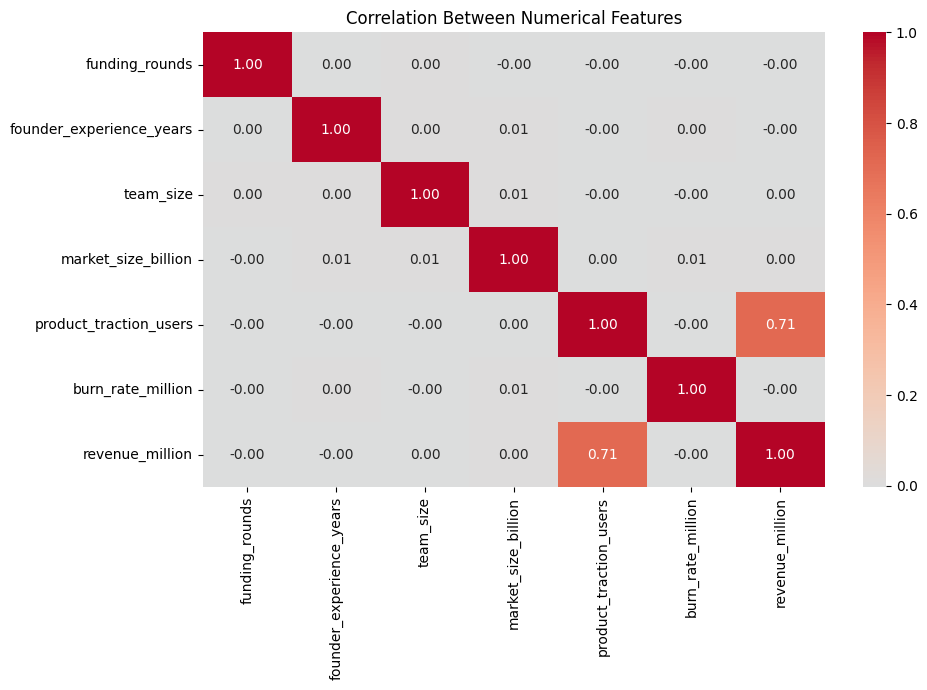

In [6]:
import seaborn as sns
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.select_dtypes("number").corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Numerical Features")
plt.tight_layout()
plt.show()

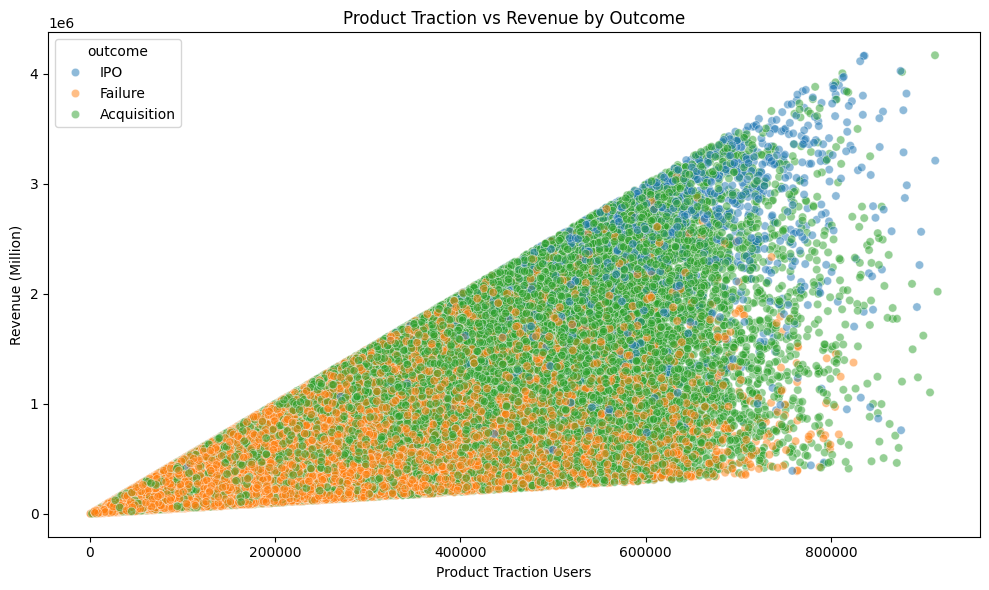

In [7]:
# Targeted Relationship

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="product_traction_users",
    y="revenue_million",
    hue="outcome",
    alpha=0.5
)

plt.title("Product Traction vs Revenue by Outcome")
plt.xlabel("Product Traction Users")
plt.ylabel("Revenue (Million)")
plt.tight_layout()
plt.show()

Your key observations are valid:
* Low traction + low revenue → more concentrated around Failure.
* High traction + high revenue → more concentrated around IPO.
* Acquisition has substantially more overlap and doesn't show as clean a boundary.
* This supports the earlier finding that traction and revenue are important variables to investigate in modeling.
* The strong correlation (0.714) also tells us these two features contain related information.


## 1. Dataset audit


In [2]:
for col in df.select_dtypes(include="number"):
    print(col, df[col].nunique(), df[col].min(), df[col].max())

funding_rounds 9 0 8
founder_experience_years 25 0 24
team_size 298 2 299
market_size_billion 100000 0.2887382859868989 1072.43447610433
product_traction_users 91579 668 915203
burn_rate_million 100000 0.2797631616181472 357.491454344996
revenue_million 100000 1344.8101775892874 4168442.502643002


In [3]:
for col in ["investor_type", "sector", "founder_background", "outcome"]:
    print(col, df[col].unique())

investor_type ['tier2_vc' 'none' 'angel' 'tier1_vc']
sector ['Health' 'Fintech' 'SaaS' 'Ecommerce' 'Climate' 'Crypto' 'AI']
founder_background ['academic' 'first_time' 'ex_bigtech' 'serial_founder']
outcome ['IPO' 'Failure' 'Acquisition']


In [6]:
df.groupby("outcome")[[
    "funding_rounds",
    "market_size_billion",
    "product_traction_users",
    "burn_rate_million",
    "revenue_million"
]].median()

,funding_rounds,market_size_billion,product_traction_users,burn_rate_million,revenue_million
outcome,,,,,
Acquisition,2.0,20.158942,342404.0,12.149473,9.491657e+05
Failure,2.0,20.131695,205908.5,12.175408,4.341426e+05
IPO,3.0,20.608426,547752.0,12.475641,2.144511e+06


In [7]:
df.groupby("outcome")[[
    "funding_rounds",
    "market_size_billion",
    "product_traction_users",
    "burn_rate_million",
    "revenue_million"
]].mean()

,funding_rounds,market_size_billion,product_traction_users,burn_rate_million,revenue_million
outcome,,,,,
Acquisition,2.346593,33.378968,350871.971844,16.833880,1.041604e+06
Failure,1.703363,33.084890,225905.483097,16.715743,5.363789e+05
IPO,2.999027,32.816629,547695.586375,17.224596,2.120475e+06


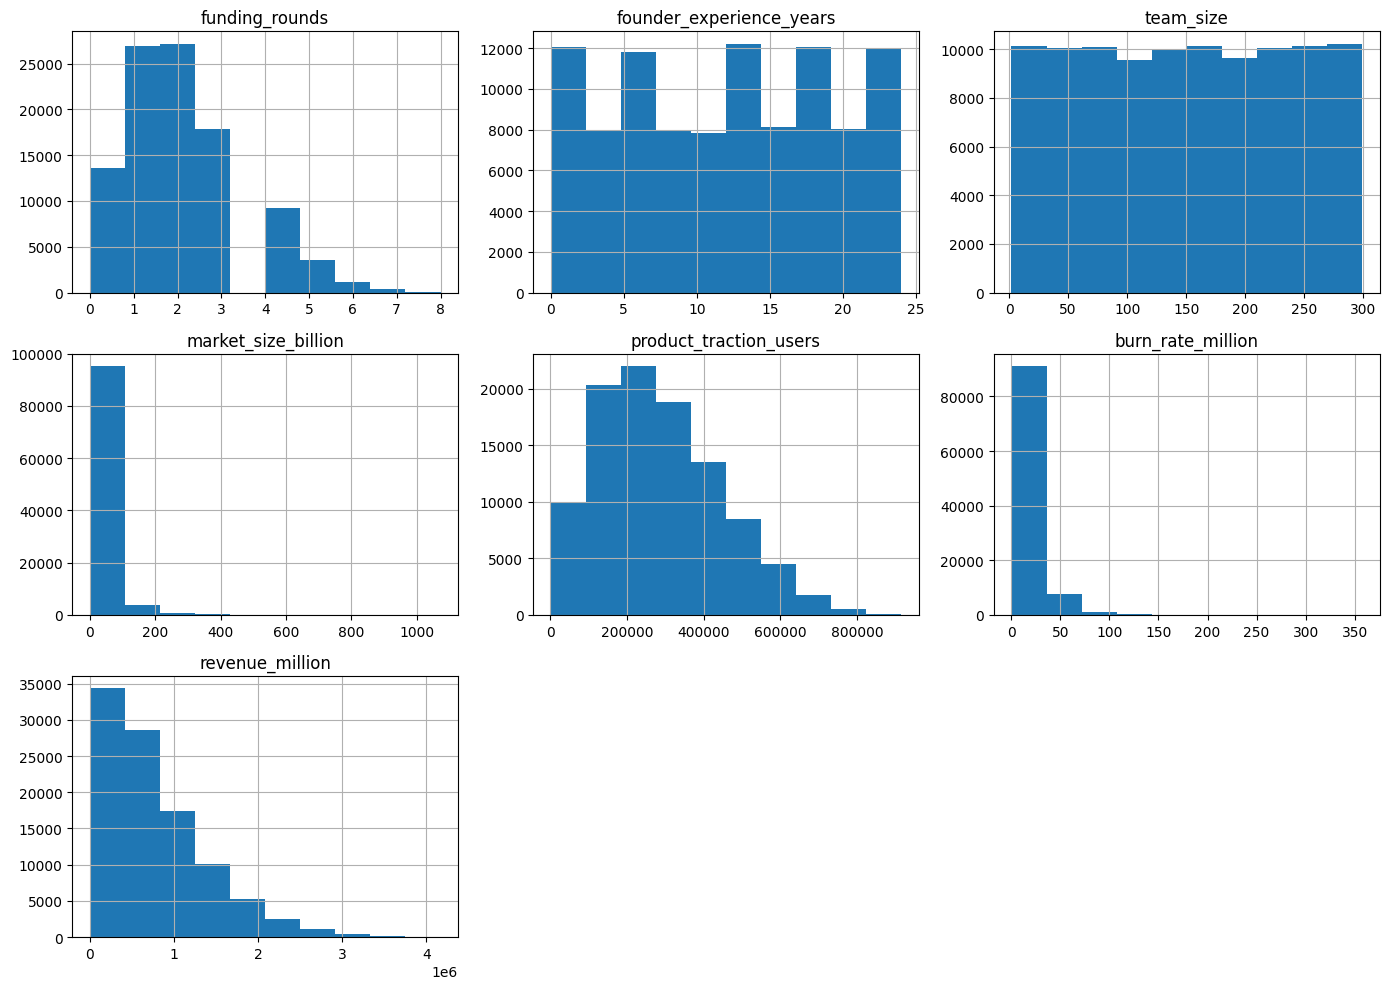

In [5]:
import matplotlib.pyplot as plt

df.hist(figsize=(14, 10))
plt.tight_layout()
plt.show()
# Right (positive) skew, clearly:
# funding_rounds — most mass at 0–3, with a long thin tail out to 8
# market_size_billion — extremely skewed; almost everything is packed near 0, with a tiny tail stretching to 1000
# product_traction_users — right-skewed, tail out toward 800k+
# burn_rate_million — very heavily right-skewed, huge spike near 0 and a thin tail to 350
# revenue_million — right-skewed, decaying tail out to ~4M
# Roughly uniform / not skewed:
# founder_experience_years — jagged but roughly flat/multimodal, not really skewed
# team_size — essentially uniform across 0–300

In [4]:
for col in df.select_dtypes(include="number").columns:
    print(col, "min =", df[col].min(), "max =", df[col].max())

funding_rounds min = 0 max = 8
founder_experience_years min = 0 max = 24
team_size min = 2 max = 299
market_size_billion min = 0.2887382859868989 max = 1072.43447610433
product_traction_users min = 668 max = 915203
burn_rate_million min = 0.2797631616181472 max = 357.491454344996
revenue_million min = 1344.8101775892874 max = 4168442.502643002


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
funding_rounds,100000.0,2.002300,1.414671,0.000000,1.000000,2.000000,3.000000e+00,8.000000e+00
founder_experience_years,100000.0,12.024300,7.208089,0.000000,6.000000,12.000000,1.800000e+01,2.400000e+01
team_size,100000.0,150.732000,86.272631,2.000000,76.000000,151.000000,2.260000e+02,2.990000e+02
market_size_billion,100000.0,33.203875,43.034753,0.288738,10.196778,20.158063,3.953197e+01,1.072434e+03
product_traction_users,100000.0,285422.832730,159323.885405,668.000000,161194.750000,264989.500000,3.892140e+05,9.152030e+05
burn_rate_million,100000.0,16.776213,15.711368,0.279763,7.087591,12.169059,2.095356e+01,3.574915e+02
revenue_million,100000.0,782819.143683,608506.910922,1344.810178,315486.092584,621362.389435,1.098921e+06,4.168443e+06


In [2]:
#categorical values 
for col in ["investor_type", "sector", "founder_background", "outcome"]:
    print(f"\n{col}")
    print(df[col].value_counts())


investor_type
investor_type
tier2_vc    35327
angel       25137
none        24866
tier1_vc    14670
Name: count, dtype: int64

sector
sector
Crypto       14456
Climate      14412
Health       14357
SaaS         14333
Fintech      14220
Ecommerce    14148
AI           14074
Name: count, dtype: int64

founder_background
founder_background
first_time        39980
ex_bigtech        25009
academic          20054
serial_founder    14957
Name: count, dtype: int64

outcome
outcome
Failure        55610
Acquisition    42335
IPO             2055
Name: count, dtype: int64


In [6]:
print(df['outcome'].value_counts())
print(df['outcome'].value_counts(normalize=True) * 100)

outcome
Failure        55610
Acquisition    42335
IPO             2055
Name: count, dtype: int64
outcome
Failure        55.610
Acquisition    42.335
IPO             2.055
Name: proportion, dtype: float64


In [5]:
print(df.isnull().sum())
print(df.nunique())
print(df.duplicated().sum())

funding_rounds              0
founder_experience_years    0
team_size                   0
market_size_billion         0
product_traction_users      0
burn_rate_million           0
revenue_million             0
investor_type               0
sector                      0
founder_background          0
outcome                     0
dtype: int64
funding_rounds                   9
founder_experience_years        25
team_size                      298
market_size_billion         100000
product_traction_users       91579
burn_rate_million           100000
revenue_million             100000
investor_type                    4
sector                           7
founder_background               4
outcome                          3
dtype: int64
0


In [4]:
print(df.shape)
print(df.info())
print(df.head())
print(df.columns.tolist())



(100000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   funding_rounds            100000 non-null  int64  
 1   founder_experience_years  100000 non-null  int64  
 2   team_size                 100000 non-null  int64  
 3   market_size_billion       100000 non-null  float64
 4   product_traction_users    100000 non-null  int64  
 5   burn_rate_million         100000 non-null  float64
 6   revenue_million           100000 non-null  float64
 7   investor_type             100000 non-null  object 
 8   sector                    100000 non-null  object 
 9   founder_background        100000 non-null  object 
 10  outcome                   100000 non-null  object 
dtypes: float64(3), int64(4), object(4)
memory usage: 8.4+ MB
None
   funding_rounds  founder_experience_years  team_size  market_size_billion  \
0  